# 18_归一化方法-二值化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这一小节，我们来把 归一化方法方面的二值化，详细的和大家聊聊\~

### 什么是二值化？

核心思想：把“复杂、多样”的数值，变成“只剩下两个选项”的简单数据。

比如原始数据可以是：

- 身高（178cm）
- 分数（95分）
- 年龄（23岁）

但我们在处理时，只关心它是不是“高”、“及格”、“成年”，就可以把它变成：

- 是（1）或 否（0）

这就是“**二值化**”。

### 为什么要用二值化？

1. **简化问题**：复杂的数字信息 → 简单的“是否”判断。
2. **方便模型处理**：有些机器学习模型处理布尔值（0或1）更高效。
3. **用于分类任务**：把原始数据转成“类别标签”。

## 二值化的基本构成

我们来从最基本的结构开始：

- 数据点：$x$（原始数据）
- 阈值：$T$（你设置的一个临界值）
- 输出：$x'$（二值化后的结果，只可能是0或1）

### 二值化数学定义


$$
x' = \begin{cases}1, & x \geq T \quad\text{（满足条件）} \\0, & x < T \quad\text{（不满足条件）}\end{cases}
$$


- 如果 $x$ 的值大于或等于你设置的那个“门槛” $T$，那么你认为这个数据“够格” → 用 **1** 表示；
- 否则你认为“不过关” → 用 **0** 表示。

### 举个最简单的例子

原始数据：学生分数：$x = [45, 59, 60, 77, 90]$

设定及格线为：$T = 60$

执行判断：

| 原始分数 $x$ | 判断 $x \geq 60?$ | 二值化结果 $x'$ |
|-|-|-|
| 45 | 否 | 0 |
| 59 | 否 | 0 |
| 60 | 是 | 1 |
| 77 | 是 | 1 |
| 90 | 是 | 1 |

最终结果：$x' = [0, 0, 1, 1, 1]$

## 从归一化的角度来理解二值化

归一化是把不同“量级”的数据统一到一个标准范围里（比如 0\~1）。

常见的归一化公式是：


$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$


它的目标是让所有数据 **在相对尺度上公平对比**。

### 二值化是最极端的归一化：

- 它不关心 **值到底是多少**；
- 它只关心你 **有没有超过某个值**。

就像：

- 原始数据有 0\~100 的范围，
- 二值化后就只剩 **两个值：0 或 1**。

## 数学原理

我们来用一个完整的数学视角，把二值化的本质推导一遍。

### 1. 原始数据：一组实数


$$
x = [x_1, x_2, ..., x_n]
$$


比如说：


$$
x = [0.2, 0.5, 0.8, 0.9]
$$


### 2. 设定一个阈值 $T$

这个阈值是你认为“分类标准线”。

比如：$T = 0.7$

### 3. 定义一个指示函数

数学上我们用：


$$
\delta(x_i) =\begin{cases}1, & x_i \geq T \\0, & x_i < T\end{cases}
$$


这个函数 $\delta(x_i)$ 就是核心的“判断逻辑”：是否超过阈值。

### 4. 得到二值化结果

把所有 $x_i$ 依次代入：


$$
x_1 = 0.2 \Rightarrow 0.2 < 0.7 \Rightarrow x'_1 = 0
$$


$$
x_2 = 0.5 \Rightarrow 0.5 < 0.7 \Rightarrow x'_2 = 0
$$


$$
x_3 = 0.8 \Rightarrow 0.8 \geq 0.7 \Rightarrow x'_3 = 1
$$


$$
x_4 = 0.9 \Rightarrow 0.9 \geq 0.7 \Rightarrow x'_4 = 1
$$


最终结果：


$$
x' = [0, 0, 1, 1]
$$


## 算法流程

我们现在把执行过程像“机器操作一样”分解，清晰每一步怎么做：

### 步骤 1：准备数据

输入一组数，例如：


$$
x = [x_1, x_2, x_3, ..., x_n]
$$


例子：


$$
x = [20, 35, 50, 65, 80]
$$


### 步骤 2：设定一个阈值 $T$

比如我们设：


$$
T = 50
$$


### 步骤 3：逐个判断并生成新值

对于每个 $x_i$：

- 如果 $x_i \geq T$，输出 1；
- 如果 $x_i < T$，输出 0。

### 步骤 4：记录结果

把所有判断后的值记录到一个新的列表中：


$$
x_1 = 20 \Rightarrow 0
$$


$$
x_2 = 35 \Rightarrow 0
$$


$$
x_3 = 50 \Rightarrow 1
$$


$$
x_4 = 65 \Rightarrow 1
$$


$$
x_5 = 80 \Rightarrow 1
$$


最终结果：


$$
x' = [0, 0, 1, 1, 1]
$$


总之，二值化是一种极简的归一化：把数据简化成 0 或 1，本质是一个“条件判断”：有没有超过某个阈值；数学形式是一个“阶梯函数”或“指示函数”，在数据处理、分类、图像黑白处理等方面很常用。

## 完整案例

在文档扫描、图像预处理、OCR（文字识别）等任务中，常需要将灰度图像转换为黑白图像，去除灰度噪声，突出文字或目标物体。二值化正是最基本、常用的预处理技术。

代码实现：

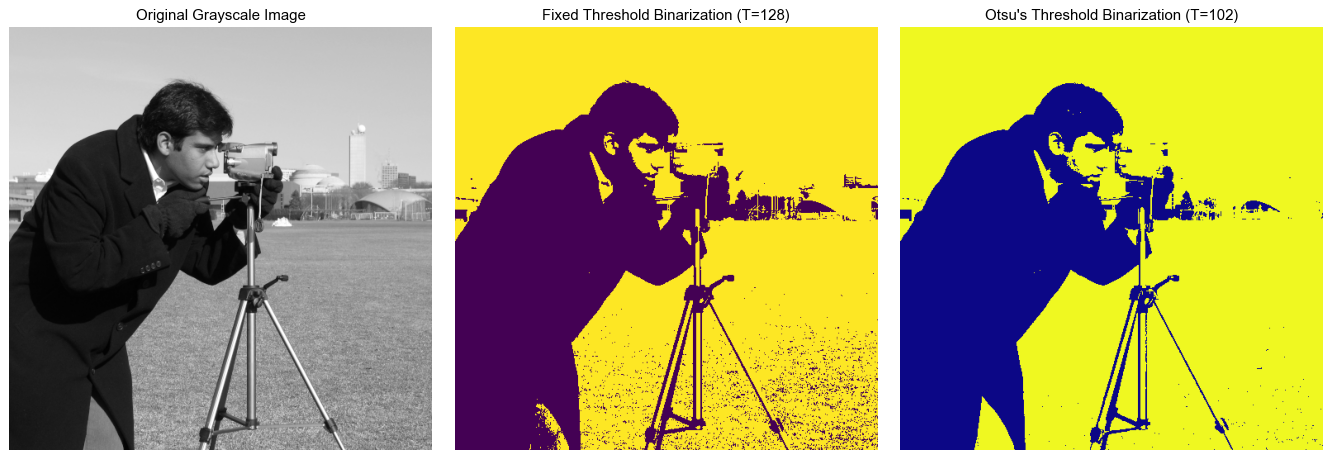

In [2]:
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.filters import threshold_otsu
import numpy as np

# 1. 读取一张样例灰度图像
image = data.camera()  # skimage 自带的摄影师和三脚架照片

# 2. 固定阈值二值化
fixed_thresh = 128
binary_fixed = image >= fixed_thresh

# 3. Otsu 自适应阈值二值化
otsu_thresh = threshold_otsu(image)
binary_otsu = image >= otsu_thresh

# 4. 可视化对比：原图 / 固定阈值 / Otsu 方法
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Grayscale Image")
ax[0].axis('off')

ax[1].imshow(binary_fixed, cmap='viridis')
ax[1].set_title(f"Fixed Threshold Binarization (T={fixed_thresh})")
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap='plasma')
ax[2].set_title(f"Otsu's Threshold Binarization (T={otsu_thresh})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

1. 第一幅图：原始灰度图（0–255）。
2. 第二幅图：固定阈值二值化（阈值 T=128），低于 128 的部分显示深紫色，高于等于 128 显示亮黄色。
3. 第三幅图：Otsu 方法自动计算阈值（本例约为 102），用深蓝与亮黄对比。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

### 代码详解

#### 1. 读取并准备原始灰度图像

In [3]:
image = data.camera()

- `image`：一个 512×512 的二维数组，每个元素范围在 0\~255，代表灰度强度。
- 我们选择这张经典的“摄影师拿三脚架”照片，作为演示对象。

### 2. 固定阈值二值化

In [4]:
fixed_thresh = 128
binary_fixed = image >= fixed_thresh

**固定阈值**：人为设定 `T=128`，这是灰度范围中点。

`image >= fixed_thresh`：将原图每个像素值与 128 比较，生成布尔数组（True/False），再转为二值（1/0）。

- 如果 ≥128 → True → 在可视化时被映射为“1”（亮色）。
- 如果 <128 → False → 映射为“0”（暗色）。

### 3. Otsu 自适应阈值二值化

In [5]:
otsu_thresh = threshold_otsu(image)
binary_otsu = image >= otsu_thresh

- **Otsu 方法**：自动根据图像灰度直方图寻找将类内方差最小化的最佳阈值。
- `threshold_otsu(image)` 返回一个整数阈值，本例约为 102。
- 接着同样比较生成二值图。

### 4. 可视化对比

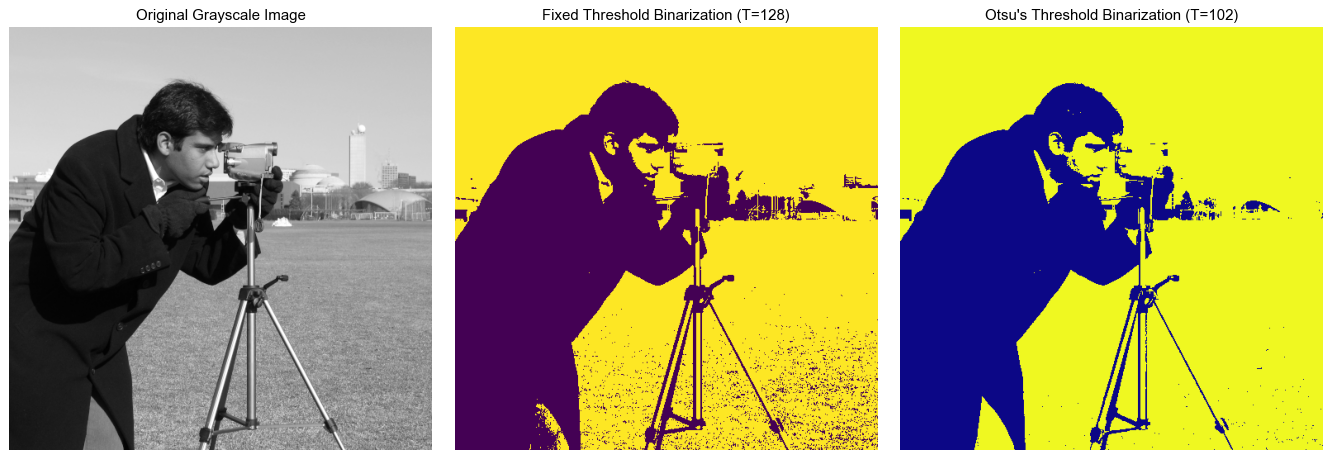

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = axes.ravel()

# 原图
ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Grayscale Image")
ax[0].axis('off')

# 固定阈值结果
ax[1].imshow(binary_fixed, cmap='viridis')
ax[1].set_title(f"Fixed Threshold Binarization (T={fixed_thresh})")
ax[1].axis('off')

# Otsu 方法结果
ax[2].imshow(binary_otsu, cmap='plasma')
ax[2].set_title(f"Otsu's Threshold Binarization (T={otsu_thresh})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

- **plt.subplots**：创建 1×3 的子图。
- **imshow(..., cmap=...)**：指定不同的伪彩色映射，让结果视觉对比更加清晰。

  - `gray`：灰度原图
  - `viridis`、`plasma`：Matplotlib 自带的亮色映射，凸显前景与背景的对比。
- `axis('off')`：去掉坐标轴以简化视图。

### 分析与讨论

#### 1. 固定阈值法：优缺点

**优点**

- 实现简单：只需一个固定数字。
- 计算效率高：比较运算 O(N)。
- 可控性好：当你明确知道图像整体亮度范围时，可以精确调整。

**缺点**

- 对“光照不均”或“对比度弱”场景鲁棒性差。
- 单一阈值无法应对局部阴影、反光等复杂情况。
- 手动选择阈值耗时且主观。

#### 2. Otsu 自适应阈值法：优缺点

**优点**

- 自动寻优：无需人工设定，适合批量处理。
- 对于双峰分布的灰度直方图效果尤佳（前景/背景明显分离）。
- 抗一定程度的灰度噪声。

**缺点**

- 计算量相对固定阈值略高（虽仍是 O(N) 但存在直方图计算和类内方差优化）。
- 对于分布不明显双峰或目标非常细小场景，效果可能欠佳。
- 无法处理局部自适应需求（比如图像不同区域光照有很大差异时）。

### 何时优选二值化方法

1. **预处理 OCR**：对文档扫描件，背景干净且对比度较好，二值化能显著提升文字识别率。
2. **目标检测**：在标定环境（光照均匀、背景单一）中快速分割目标。
3. **图像压缩与存储**：黑白二值图可大幅减少存储空间（1 bit/pixel）。
4. **工业检测**：高速相机采集流水线物体，二值化后可更快检测缺陷或计数。

**不适合**：光照复杂、目标与背景灰度重叠严重、需要保留丰富灰度信息或颜色信息的场景。

## 总结

总体来说：二值化是最简单的归一化方法，将连续灰度转换为黑白两级。

**阈值选择**：决定处理效果，固定阈值适合已知场景，Otsu 更具通用性。

**应用场景**：OCR、简单分割、工业检测、节省存储等。

**局限性**：光照依赖强，无法保留细腻灰度，需结合其他预处理手段（均衡化、滤波、形态学操作）共同使用。